
# Ce que les capteurs disent et que le modèle n'écoute pas

Le premier carnet a reproduit une calibration de référence : un modèle de demande construit sur
les compteurs communicants, puis un ajustement des rugosités par groupes de conduites. Le
résultat était honnête mais modeste, et une part importante de l'erreur restante était un
**biais** — c'est-à-dire, précisément, la part qui ne dit rien de la dynamique.

Ce carnet prend le problème par l'autre bout. Plutôt que de raffiner le modèle de consommation,
il regarde les **conditions aux limites** : ce que le réseau reçoit, ce qu'il stocke, et comment
le modèle en rend compte. Quatre leviers, tous lisibles dans des capteurs déjà installés.

| | levier | mesure utilisée |
|---|---|---|
| 1 | l'état réel de la pompe | débitmètre de la pompe |
| 2 | l'ancrage du niveau du réservoir | capteur de niveau |
| 3 | la section réelle du réservoir | bilan volumique par demi-cycle |
| 4 | le niveau de la demande | bilan de masse aux débitmètres d'entrée |

Deux d'entre eux transforment le résultat. Un troisième corrige un biais sans rien changer à la
dynamique. Le quatrième ne donne rien — et la raison pour laquelle il ne donne rien est la partie
la plus utile de ce carnet.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from calibration import reseau as R, profils as P, rugosite as U, ameliorations as A, diagnostics as G

plt.rcParams.update({"figure.figsize": (10, 3.2), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

ANNEE = 2018
DEBUT = 181 * R.PAS_JOUR
N_PAS = 7 * R.PAS_JOUR
N_ENTR = 2 * R.PAS_JOUR

R.verifier_donnees(ANNEE)
wn = R.charger_modele(duree_h=24)
noeuds = wn.junction_name_list
horo = R.horodatage(ANNEE)
mesure = R.charger_pressions(ANNEE).to_numpy()[DEBUT:DEBUT + N_PAS]
niveau = R.charger_niveau(ANNEE).to_numpy()
debits = R.charger_debits(ANNEE)

formes = P.formes_par_categorie(wn, ANNEE)           # le modèle de demande du carnet 1 (~15 s)
D_calibre, _ = P.demandes_calibrees(wn, ANNEE, formes)
print("prêt")

prêt



## 1. La pompe suit une consigne, pas la réalité

Le fichier de réseau pilote la pompe par deux contrôles sur le niveau du réservoir :

```
LINK PUMP_1 CLOSED IF NODE T1 ABOVE 3.9000
LINK PUMP_1 OPEN   IF NODE T1 BELOW 2.4000
```

C'est une règle plausible, et c'est une **hypothèse**. La vraie pompe est commandée autrement, et
son débit est mesuré : on peut donc comparer l'hypothèse à la réalité au lieu de la supposer.

In [2]:
statut_mesure = A.statut_pompe(ANNEE)

def statut_simule(n=N_PAS):
    # relit l'état de la pompe décidé par les contrôles du modèle
    D = D_calibre[DEBUT:DEBUT + n + 1]
    out = R.simuler(D, noeuds, n,
                    lambda res, w, a, b: res.link["status"]["PUMP_1"].to_numpy()[:b - a],
                    tranche_jours=7, niveau0=float(niveau[DEBUT]), verbeux=False)
    return np.concatenate(out)

st_sim = statut_simule()
st_mes = statut_mesure[DEBUT:DEBUT + N_PAS]

print(f"pompe en marche : {st_mes.mean():.1%} du temps mesuré, {st_sim.mean():.1%} simulé")
print(f"basculements sur la fenêtre : {len(A.transitions(st_mes))} mesurés, "
      f"{len(A.transitions(st_sim))} simulés")
print(f"états en désaccord : {(st_sim != st_mes).mean():.1%} des pas")

pompe en marche : 65.0% du temps mesuré, 49.1% simulé
basculements sur la fenêtre : 14 mesurés, 14 simulés
états en désaccord : 22.8% des pas


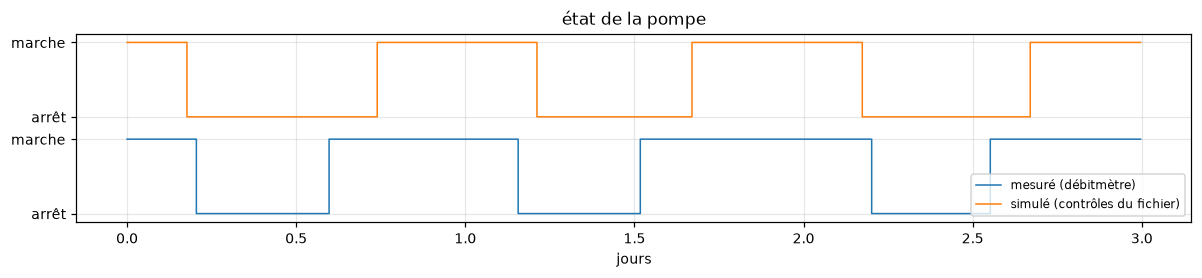

In [3]:
fig, ax = plt.subplots(figsize=(11, 2.6))
j = np.arange(3 * R.PAS_JOUR) / R.PAS_JOUR
ax.step(j, st_mes[:len(j)], lw=1.0, label="mesuré (débitmètre)")
ax.step(j, st_sim[:len(j)] + 1.3, lw=1.0, label="simulé (contrôles du fichier)")
ax.set_yticks([0, 1, 1.3, 2.3]); ax.set_yticklabels(["arrêt", "marche", "arrêt", "marche"])
ax.set_xlabel("jours"); ax.legend(fontsize=8); ax.set_title("état de la pompe")
fig.tight_layout()

In [4]:
# Que vaut la pompe, en mètres de pression, dans les données mesurées ?
p_mes = R.charger_pressions(ANNEE).to_numpy()
marche = statut_mesure.astype(bool)
entrant = (debits["p227"] + debits["p235"]).to_numpy()

print(f"débit entrant : {entrant[marche].mean():.0f} m³/h pompe en marche, "
      f"{entrant[~marche].mean():.0f} m³/h à l'arrêt "
      f"(+{100 * (entrant[marche].mean() / entrant[~marche].mean() - 1):.0f} %)")
print(f"la pompe prélève à elle seule {debits['PUMP_1'][marche].mean():.0f} m³/h, soit "
      f"{100 * debits['PUMP_1'][marche].mean() / entrant[marche].mean():.0f} % de ce qui entre")
print(f"\npression moyenne aux 33 capteurs : {p_mes[marche].mean():.3f} m en marche, "
      f"{p_mes[~marche].mean():.3f} m à l'arrêt "
      f"(écart {p_mes[marche].mean() - p_mes[~marche].mean():+.3f} m)")

ecart = pd.Series(p_mes[marche].mean(axis=0) - p_mes[~marche].mean(axis=0),
                  index=R.capteurs()["pressure"])
print("\ncapteurs les plus sensibles à l'état de la pompe :")
print(ecart.sort_values().head(4).round(3).to_string())

débit entrant : 217 m³/h pompe en marche, 178 m³/h à l'arrêt (+22 %)
la pompe prélève à elle seule 44 m³/h, soit 20 % de ce qui entre

pression moyenne aux 33 capteurs : 46.099 m en marche, 46.452 m à l'arrêt (écart -0.353 m)

capteurs les plus sensibles à l'état de la pompe :
n54    -0.913
n410   -0.781
n429   -0.772
n342   -0.582



Voilà le mécanisme, mesuré et non supposé. La pompe n'est pas un détail du réservoir : elle
prélève un cinquième de tout ce qui entre dans le réseau. Quand elle démarre, le débit dans les
conduites de transport augmente d'un cinquième, la perte de charge le long de ces conduites
augmente avec, et **toutes** les pressions du réseau descendent — d'un tiers de mètre en moyenne,
de près d'un mètre sur les capteurs proches de l'arrivée.

Se tromper d'état de pompe un pas sur cinq revient donc à injecter cet écart dans le résidu un
pas sur cinq, avec le signe qui va bien. C'est du même ordre que l'erreur totale qu'on cherche à
expliquer.

Le remède ne demande aucun modèle : on remplace les deux contrôles par le profil d'état lu au
débitmètre.

## 2. Le réservoir se bloque

Mais retirer les contrôles retire aussi la seule chose qui régulait le niveau du réservoir. La
pompe étant désormais commandée de l'extérieur, le niveau devient l'intégrale libre de l'écart
entre ce qui entre et ce que le modèle croit consommer. Une petite erreur de demande, constante,
s'accumule.

mesuré                     : de 2.39 à 3.90 m
sans ancrage               : de 2.86 à 4.00 m, saturé sur 20% des pas, écart moyen au capteur 0.51 m
réancré chaque jour        : de 2.55 à 4.00 m, saturé sur  9% des pas, écart moyen au capteur 0.38 m
réancré toutes les 6 h     : de 2.39 à 4.00 m, saturé sur  2% des pas, écart moyen au capteur 0.11 m


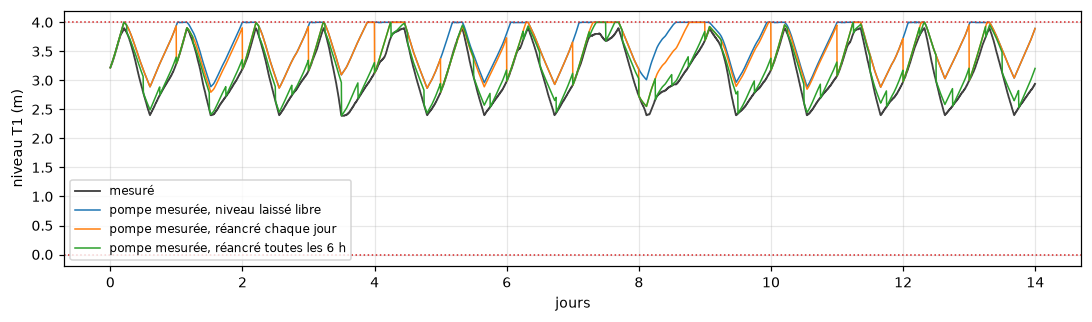

In [5]:
def niveau_simule(tranche, ancrage, n=14 * R.PAS_JOUR):
    kw = dict(pompe=statut_mesure[DEBUT:DEBUT + n + 1])
    if ancrage:
        kw["niveau_mesure"] = niveau[DEBUT:DEBUT + n + 1]
    out = R.simuler(D_calibre[DEBUT:DEBUT + n + 1], noeuds, n,
                    lambda res, w, a, b: (res.node["head"]["T1"].to_numpy()[:b - a]
                                          - w.get_node("T1").elevation),
                    tranche_jours=tranche, niveau0=float(niveau[DEBUT]), verbeux=False, **kw)
    return np.concatenate(out)

libre = niveau_simule(14, ancrage=False)
ancre = niveau_simule(1, ancrage=True)
serre = niveau_simule(0.25, ancrage=True)          # réancrage toutes les 6 heures

fig, ax = plt.subplots(figsize=(10, 3.0))
j = np.arange(len(libre)) / R.PAS_JOUR
ax.plot(j, niveau[DEBUT:DEBUT + len(libre)], lw=1.2, color="0.25", label="mesuré")
ax.plot(j, libre, lw=1.0, label="pompe mesurée, niveau laissé libre")
ax.plot(j, ancre, lw=1.0, label="pompe mesurée, réancré chaque jour")
ax.plot(j, serre, lw=1.0, label="pompe mesurée, réancré toutes les 6 h")
ax.axhline(4.0, color="C3", ls=":", lw=1); ax.axhline(0.0, color="C3", ls=":", lw=1)
ax.set_xlabel("jours"); ax.set_ylabel("niveau T1 (m)"); ax.legend(fontsize=8)
fig.tight_layout()

vrai = niveau[DEBUT:DEBUT + len(libre)]
sature = lambda h: np.mean((h <= 0.001) | (h >= 3.999))
ecart = lambda h: np.abs(h - vrai[:len(h)]).mean()
print(f"mesuré                     : de {vrai.min():.2f} à {vrai.max():.2f} m")
for nom, h in [("sans ancrage", libre), ("réancré chaque jour", ancre),
               ("réancré toutes les 6 h", serre)]:
    print(f"{nom:27s}: de {h.min():.2f} à {h.max():.2f} m, saturé sur {sature(h):3.0%} des pas, "
          f"écart moyen au capteur {ecart(h):.2f} m")


Sans ancrage, le niveau part et vient **buter contre le trop-plein**, où il reste collé une
bonne partie du temps. Un réservoir saturé ne joue plus son rôle : il absorbe ou fournit ce qu'on
veut sans que son niveau bouge, et la zone qu'il alimente devient fausse. La dérive est
proportionnelle à l'erreur de demande accumulée, donc plus forte en été, quand la consommation
est la plus mal connue.

L'ancrage — repartir, à chaque tranche de simulation, du niveau **lu au capteur** — coûte une
ligne, et son efficacité se règle d'un paramètre : plus les tranches sont courtes, moins l'erreur
a le temps de s'accumuler, et le prix à payer est uniquement du temps de calcul. Il ne supprime
pas complètement la saturation, il la borne. Les deux leviers sont indissociables : le premier
sans le second ne tient pas.

## 3. Ce que valent les deux leviers, et comment ils se composent

Il est tentant de tester un changement à la fois. Voyons ce que cela donne : croisons le modèle
de demande et les conditions aux limites, sur deux saisons.

In [6]:
def croiser(debut, n=3 * R.PAS_JOUR):
    mes = R.charger_pressions(ANNEE).to_numpy()[debut:debut + n]
    D_nom, _ = P.demandes_nominales(wn, horo[debut:debut + n + 1])
    bc = {"contrôles du fichier": {},
          "pompe mesurée + ancrage": dict(pompe=statut_mesure[debut:debut + n + 1],
                                          niveau_mesure=niveau[debut:debut + n + 1])}
    dem = {"modèle livré": D_nom, "modèle de demande": D_calibre[debut:debut + n + 1]}
    lignes = {}
    for nd, D in dem.items():
        for nb, kw in bc.items():
            S = R.pressions_simulees(D, noeuds, n, tranche_jours=1,
                                     niveau0=float(niveau[debut]), verbeux=False, **kw)
            lignes[(nd, nb)] = G.resume(S, mes)
    return pd.DataFrame(lignes).T

croise = pd.concat({"janvier": croiser(3 * R.PAS_JOUR), "juillet": croiser(DEBUT)})
print(croise[["biais_m", "dispersion_m", "rmse_m"]].round(4).to_string())

                                                   biais_m  dispersion_m  rmse_m
janvier modèle livré      contrôles du fichier     -0.1428        0.2162  0.2591
                          pompe mesurée + ancrage  -0.1141        0.1623  0.1984
        modèle de demande contrôles du fichier      0.0537        0.1311  0.1416
                          pompe mesurée + ancrage   0.0481        0.0710  0.0858
juillet modèle livré      contrôles du fichier      0.3320        0.3090  0.4535
                          pompe mesurée + ancrage   0.3014        0.2285  0.3782
        modèle de demande contrôles du fichier      0.2099        0.2460  0.3233
                          pompe mesurée + ancrage   0.1858        0.1852  0.2623



### Lecture

Regardons la colonne `dispersion_m`, celle qui porte la dynamique. Les deux leviers gagnent
séparément, et ils gagnent surtout ensemble.

Ce qui mérite d'être relevé, c'est **comment** les gains se composent. En juillet, ils se
multiplient presque exactement : chacun retire environ un quart et un cinquième de la dispersion,
et le couple en retire quarante pour cent. En janvier, le couple fait nettement mieux que cette
composition — les deux gains isolés laissaient attendre la moitié de la dispersion, on en garde
un tiers.

Autrement dit, **corriger la pompe ne fait pas que retirer sa propre erreur : cela rend le modèle
de demande plus rentable qu'il ne l'était.** C'est logique une fois dit — tant que la pompe
bascule au mauvais moment, elle injecte dans le résidu un écart qui recouvre partiellement ce que
le modèle de demande apporterait.

La leçon de méthode vaut au-delà de ce réseau : **mesurer les améliorations une par une, dans un
modèle où un autre facteur est encore mal spécifié, sous-estime leur valeur commune.** Un tableau
croisé coûte quatre simulations au lieu de deux, et il évite d'écarter un raffinement au vu d'un
gain isolé décevant.

À noter aussi, et cela resservira : le plus gros levier unique de ce tableau n'est pas le modèle
de consommation, c'est **une condition aux limites lue dans un capteur déjà installé**.

## 4. La section du réservoir : mesurable en principe, pas en pratique

Le diamètre du réservoir inscrit dans le modèle est un nombre rond — 16,00 m — c'est-à-dire une
valeur de catalogue plutôt qu'une mesure. Or il devrait se retrouver dans les données sans jamais
inverser le modèle hydraulique. Sur tout intervalle où la pompe ne change pas d'état, le
réservoir n'a qu'une entrée (mesurée) et qu'une sortie :

$$ A \cdot \Delta h = \int (Q_{\text{pompe}} - Q_{\text{zone C}})\,dt $$

Chaque demi-cycle de pompe fournit un point. Il y en a plusieurs centaines dans l'année.

section du modèle           : 201.1 m²  (diamètre 16.00 m)
estimée, erreur sur volumes : 207.9 m²  (diamètre 16.27 m)
estimée, erreur sur niveaux : 414.0 m²  (diamètre 22.96 m)


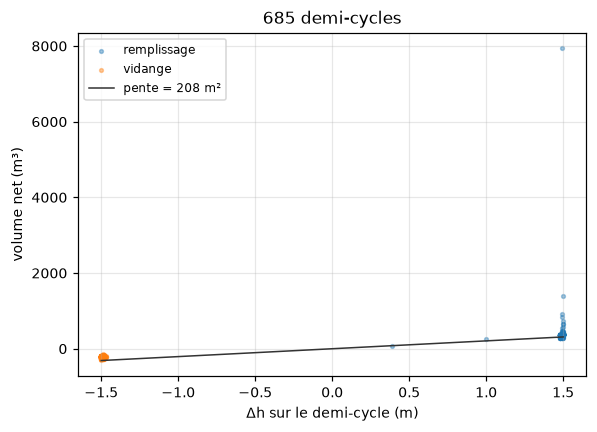

In [7]:
sec = A.section_par_demi_cycles(wn, ANNEE)
cycles = sec["demi_cycles"]

fig, ax = plt.subplots(figsize=(5.5, 4.0))
for p, lib, c in [(1, "remplissage", "C0"), (0, "vidange", "C1")]:
    s = cycles[cycles.pompe == p]
    ax.scatter(s.dh, s.V_net, s=6, alpha=0.4, color=c, label=lib)
x = np.linspace(cycles.dh.min(), cycles.dh.max(), 10)
ax.plot(x, sec["section_m2"] * x, color="0.2", lw=1, label=f"pente = {sec['section_m2']:.0f} m²")
ax.set_xlabel("Δh sur le demi-cycle (m)"); ax.set_ylabel("volume net (m³)")
ax.legend(fontsize=8); ax.set_title(f"{sec['n_demi_cycles']} demi-cycles")
fig.tight_layout()

print(f"section du modèle           : {sec['section_du_modele_m2']:.1f} m²  "
      f"(diamètre {sec['diametre_du_modele_m']:.2f} m)")
print(f"estimée, erreur sur volumes : {sec['encadrement_m2'][0]:.1f} m²  "
      f"(diamètre {sec['encadrement_diametre_m'][0]:.2f} m)")
print(f"estimée, erreur sur niveaux : {sec['encadrement_m2'][1]:.1f} m²  "
      f"(diamètre {sec['encadrement_diametre_m'][1]:.2f} m)")


Le nuage est convaincant et les deux estimateurs sont **incompatibles** : selon le sens dans
lequel on ajuste la droite, la section varie du simple au double. Chacun pris seul aurait donné
une barre d'erreur étroite et rassurante.

L'explication tient en un nombre.

In [8]:
print(f"corrélation entre volume pompé et volume consommé, sur un remplissage : "
      f"{sec['correlation_remplissage']:.3f}")
print(f"si l'on laisse la consommation de la zone C libre d'un facteur d'échelle :")
print(f"   section {sec['section_echelle_libre_m2']:.1f} m², "
      f"facteur sur la consommation ×{sec['echelle_zoneC']:.2f}")

corrélation entre volume pompé et volume consommé, sur un remplissage : 0.997
si l'on laisse la consommation de la zone C libre d'un facteur d'échelle :
   section 228.4 m², facteur sur la consommation ×1.72



Sur un demi-cycle de remplissage, le volume pompé et le volume consommé sont tous deux
proportionnels à la durée du cycle : ils sont colinéaires à 0,997. Deux régresseurs colinéaires
ne se séparent pas, quelle que soit la quantité de données — on mesure en réalité **une
combinaison** de la section du réservoir et de la consommation non comptée de la zone qu'il
alimente. Laisser cette dernière libre absorbe l'écart sans difficulté, ce qui est la définition
même d'un paramètre non identifiable.

Et il y a une bonne nouvelle dans ce résultat négatif : puisque le levier 2 réancre le niveau sur
son capteur à chaque tranche, la section ne gouverne plus que la dynamique **à l'intérieur** d'une
tranche. Vérifions que cela ne change effectivement rien.

In [9]:
bc = dict(pompe=statut_mesure[DEBUT:DEBUT + N_PAS + 1], niveau_mesure=niveau[DEBUT:DEBUT + N_PAS + 1])
faire = lambda D, **kw: R.pressions_simulees(D, noeuds, N_PAS, tranche_jours=1,
                                             niveau0=float(niveau[DEBUT]), verbeux=False, **kw)

S_bc = faire(D_calibre[DEBUT:DEBUT + N_PAS + 1], **bc)
S_sec = faire(D_calibre[DEBUT:DEBUT + N_PAS + 1], **bc,
              diametre_T1=sec["encadrement_diametre_m"][0])

print(G.tableau({"section du modèle": S_bc, "section estimée": S_sec}, mesure).round(4).to_string())

                   biais_m  dispersion_m  rmse_m   max_m   n_pas  gain_dispersion  gain_rmse
section du modèle   0.1842        0.1947  0.2680  1.7186  2016.0           0.0000      0.000
section estimée     0.1842        0.1958  0.2688  1.7463  2016.0           0.0057      0.003



Rien, comme prévu. Le levier 3 est donc à écarter — non pas parce que la section serait juste,
mais parce qu'elle n'est ni identifiable ni influente une fois le niveau ancré. C'est le genre de
conclusion qu'il vaut mieux établir en une demi-heure que supposer pendant un mois.

## 5. Le niveau de la demande est mesuré, pas à modéliser

Dernier levier. La consommation totale de la grande zone n'a pas besoin d'être modélisée : elle
se lit par différence entre les débitmètres d'entrée et celui de la pompe. Le modèle de demande
garde la répartition entre nœuds et la forme temporelle ; on ne lui impose que le niveau
d'ensemble, par blocs d'une semaine.

In [10]:
D_recale = A.recaler_zone_ab(D_calibre, noeuds, wn, ANNEE, periode=R.PAS_SEMAINE)
S_bilan = faire(D_recale[DEBUT:DEBUT + N_PAS + 1], **bc)

print(G.tableau({"modèle de demande": S_bc, "+ bilan de masse": S_bilan}, mesure).round(4).to_string())

                   biais_m  dispersion_m  rmse_m   max_m   n_pas  gain_dispersion  gain_rmse
modèle de demande   0.1842        0.1947  0.2680  1.7186  2016.0           0.0000     0.0000
+ bilan de masse    0.1526        0.1946  0.2473  1.7186  2016.0          -0.0004    -0.0773



Le biais tombe, la dispersion ne bouge pas. C'est exactement ce qu'on doit attendre : un niveau
de demande trop bas déplace toutes les pressions dans le même sens, donc produit un **décalage**,
et corriger un décalage ne change rien à la dynamique.

Ce levier vaut donc pour ce qu'il est — un modèle mieux centré, utile dès qu'on compare des
pressions absolues — et pas pour ce qu'il n'est pas.

⚠️ **Une réserve importante.** Le débit d'entrée contient tout ce qui sort du réseau, y compris ce
qui fuit. Recaler la demande sur le bilan de masse **absorbe donc les fuites dans la demande**.
C'est sans conséquence pour calibrer un modèle hydraulique, et c'est rédhibitoire si l'on compte
ensuite chercher des fuites dans le résidu : dans ce cas, il faut ajuster le recalage sur une
période saine et le transporter, sans jamais le laisser suivre la mesure en continu.

## 6. Retour sur les rugosités

Le premier carnet a ajusté six facteurs de rugosité pour un gain modeste, et a renvoyé
l'explication ici. Reprenons la question dans les bonnes conditions aux limites, et commençons par
le contrôle le plus simple : **un seul** facteur, appliqué à tout le réseau, balayé.

In [11]:
groupes = R.groupes_de_rugosite(wn, n_groupes=6)
noms_groupes = sorted(set(groupes.values()))
mesure_entr = R.charger_pressions(ANNEE).to_numpy()[DEBUT:DEBUT + N_ENTR]
bc_entr = dict(pompe=statut_mesure[DEBUT:DEBUT + N_ENTR + 1],
               niveau_mesure=niveau[DEBUT:DEBUT + N_ENTR + 1])

def simulateur(facteurs):
    return R.pressions_simulees(D_recale[DEBUT:DEBUT + N_ENTR + 1], noeuds, N_ENTR,
                                tranche_jours=1, niveau0=float(niveau[DEBUT]), verbeux=False,
                                rugosite=U.facteurs_par_conduite(groupes, facteurs), **bc_entr)

bal = U.balayage(simulateur, mesure_entr, noms_groupes,
                 valeurs=(0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15), verbeux=False)
print(bal.round(4).to_string(index=False))

 facteur   rmse   biais  dispersion
    0.85 0.2562 -0.1135      0.2297
    0.90 0.1934 -0.0030      0.1934
    0.95 0.2026  0.0915      0.1807
    1.00 0.2537  0.1727      0.1858
    1.05 0.3159  0.2432      0.2017
    1.10 0.3773  0.3047      0.2225
    1.15 0.4344  0.3588      0.2449


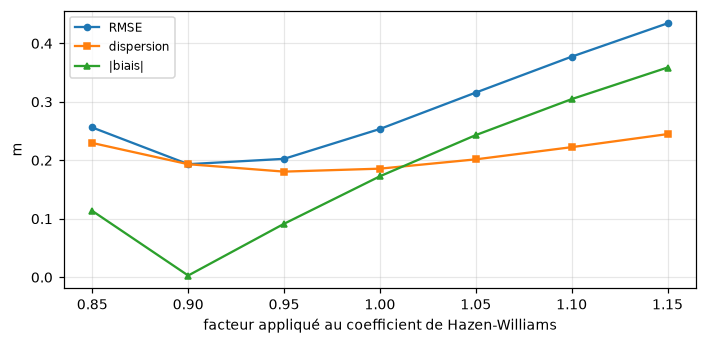

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(bal.facteur, bal.rmse, marker="o", ms=4, label="RMSE")
ax.plot(bal.facteur, bal.dispersion, marker="s", ms=4, label="dispersion")
ax.plot(bal.facteur, np.abs(bal.biais), marker="^", ms=4, label="|biais|")
ax.set_xlabel("facteur appliqué au coefficient de Hazen-Williams"); ax.set_ylabel("m")
ax.legend(fontsize=8)
fig.tight_layout()


Voilà la figure qui résume le problème. La RMSE a bien un minimum net, et ce minimum tombe
exactement **là où le biais change de signe**. La dispersion, elle, bouge à peine sur toute la
plage, et son propre minimum n'est pas au même endroit : au facteur qui optimise la RMSE, la
dispersion est *moins bonne* qu'à facteur 1.

Autrement dit, ajuster la rugosité ne fait pas mieux coller le modèle au réseau : cela déplace
toutes les pressions en bloc jusqu'à compenser une erreur de niveau qui n'a rien à voir avec la
friction. C'est un paramètre physique utilisé comme une constante d'étalonnage. Cela améliore une
métrique sans améliorer le modèle — et l'on ne peut le voir qu'en séparant le biais de la
dispersion.

Pourquoi si peu de prise ? Il suffit de regarder ce que les conduites perdent réellement.

In [13]:
pertes = U.pertes_de_charge(D_recale[DEBUT:DEBUT + R.PAS_JOUR + 1], noeuds, R.PAS_JOUR,
                            tranche_jours=1, niveau0=float(niveau[DEBUT]), verbeux=False,
                            pompe=statut_mesure[DEBUT:DEBUT + R.PAS_JOUR + 1],
                            niveau_mesure=niveau[DEBUT:DEBUT + R.PAS_JOUR + 1])

print(f"perte de charge médiane d'une conduite : {pertes.mediane_m.median() * 1000:.2f} mm")
print(f"9 conduites sur 10 sont sous            : {pertes.mediane_m.quantile(0.9) * 1000:.2f} mm")
print(f"perte maximale observée                 : {pertes.maximum_m.max() * 1000:.0f} mm")
print()
print("part de la friction totale portée par les conduites les plus chargées :")
print(U.concentration(pertes).round(3).to_string())
print()
print("les dix conduites les plus chargées :")
print(pertes.head(10).round({"mediane_m": 4, "maximum_m": 4}).to_string())

perte de charge médiane d'une conduite : 4.20 mm
9 conduites sur 10 sont sous            : 44.12 mm
perte maximale observée                 : 463 mm

part de la friction totale portée par les conduites les plus chargées :
1 % des conduites     0.129
5 % des conduites     0.377
10 % des conduites    0.562
25 % des conduites    0.819
50 % des conduites    0.950

les dix conduites les plus chargées :
      mediane_m  maximum_m  longueur_m  diametre_mm
p110     0.3492     0.4635     69.0704        200.0
p105     0.2633     0.3365     50.1743        100.0
p235     0.1869     0.2475     36.1780        200.0
p479     0.1781     0.2426     44.8971        100.0
p480     0.1698     0.2331     44.8925        100.0
p228     0.1433     0.2071     46.7558        150.0
p189     0.1408     0.1798     55.1111        100.0
p220     0.1265     0.1614     69.6172        100.0
p227     0.1262     0.1638     26.9092        200.0
p839     0.1235     0.1563     56.3034        100.0



Deux choses sautent aux yeux. D'abord, **le réseau est presque sans friction** : la conduite
médiane perd quelques millimètres de charge, si bien que changer son coefficient de 10 % la
déplacerait d'une fraction de millimètre — alors que les capteurs sont arrondis au centimètre et
que l'écart à expliquer se compte en dizaines de centimètres. Ensuite, la friction qui existe est
**très concentrée** : un dixième des conduites en porte plus de la moitié, et les premières du
classement sont les conduites d'arrivée et de transport, celles-là mêmes dont le débit dépend de
l'état de la pompe.

Les centaines de conduites restantes ne portent donc aucune information exploitable. Les
regrouper en six familles plutôt qu'en une seule ajoute cinq paramètres qui n'ont presque rien à
identifier — et un paramètre sans information ne reste pas inerte, il se met au service de
l'erreur qui domine la fenêtre d'ajustement.

In [14]:
# chaque colonne du jacobien coûte une simulation de plus : le nombre d'évaluations réelles
# est bien supérieur à `max_nfev`, qui ne compte que les évaluations principales
ajustement = U.ajuster(simulateur, mesure_entr, noms_groupes, max_nfev=12, verbeux=False)
print(f"{ajustement['n_evaluations']} simulations en {ajustement['secondes']:.0f} s ; "
      f"RMSE d'ajustement {ajustement['rmse_depart']:.4f} → {ajustement['rmse']:.4f} m")
print(pd.Series(ajustement["facteurs"]).round(3).to_string())

85 simulations en 96 s ; RMSE d'ajustement 0.2537 → 0.2202 m
D100     0.972
D150     0.983
D160     0.998
D200     0.964
D225     1.000
D<=75    1.001



Vérifions-le. Un seul test tranche vraiment pour une calibration — **est-ce que ça transfère ?**
Jugeons les deux jeux de facteurs sur la fenêtre qui a servi à les régler, puis sur deux périodes
de l'année qui n'ont servi à rien.

In [15]:
meilleur = float(bal.loc[bal.rmse.idxmin(), "facteur"])
jeux = {"sans ajustement": None,
        f"un facteur global ×{meilleur:g}": {g: meilleur for g in noms_groupes},
        "six facteurs (Levenberg-Marquardt)": ajustement["facteurs"]}

def sur_fenetre(debut, n=N_PAS):
    mes = R.charger_pressions(ANNEE).to_numpy()[debut:debut + n]
    kw = dict(pompe=statut_mesure[debut:debut + n + 1], niveau_mesure=niveau[debut:debut + n + 1])
    sorties = {}
    for nom, rg in jeux.items():
        sorties[nom] = R.pressions_simulees(
            D_recale[debut:debut + n + 1], noeuds, n, tranche_jours=1,
            niveau0=float(niveau[debut]), verbeux=False,
            rugosite=None if rg is None else U.facteurs_par_conduite(groupes, rg), **kw)
    return G.tableau(sorties, mes)

transfert = pd.concat({"juillet (fenêtre d'ajustement)": sur_fenetre(DEBUT),
                       "octobre (jamais vu)": sur_fenetre(275 * R.PAS_JOUR),
                       "janvier (jamais vu)": sur_fenetre(3 * R.PAS_JOUR)})
print(transfert[["biais_m", "dispersion_m", "rmse_m", "gain_dispersion"]].round(4).to_string())

                                                                   biais_m  dispersion_m  rmse_m  gain_dispersion
juillet (fenêtre d'ajustement) sans ajustement                      0.1526        0.1946  0.2473           0.0000
                               un facteur global ×0.9              -0.0250        0.2208  0.2223           0.1350
                               six facteurs (Levenberg-Marquardt)   0.1049        0.1957  0.2221           0.0058
octobre (jamais vu)            sans ajustement                      0.1803        0.2168  0.2820           0.0000
                               un facteur global ×0.9              -0.0126        0.2587  0.2590           0.1935
                               six facteurs (Levenberg-Marquardt)   0.1284        0.2220  0.2565           0.0239
janvier (jamais vu)            sans ajustement                      0.0505        0.0812  0.0957           0.0000
                               un facteur global ×0.9              -0.0527        0.0741


Le tableau est sans ambiguïté, et il se lit en oubliant la colonne RMSE.

Le **facteur global** est celui que la colonne RMSE désigne comme le meilleur, et c'est le plus
mauvais des trois pour la dynamique : il dégrade la dispersion de 13 % en juillet et de 19 % en
octobre, et ne l'améliore qu'en janvier, où il restait peu de biais à absorber. Il ne calibre pas
la friction, il compense un décalage — et là où le décalage est grand, il le paie en dynamique.

Les **six facteurs** sont plus sages, et c'est tout ce qu'on peut en dire : la dispersion bouge
de moins de 3 % sur la fenêtre d'ajustement comme en octobre, et gagne 11 % en janvier. Les
valeurs retenues restent à quelques pour cent de 1 — l'optimiseur ne trouve pas grand-chose à
quoi s'accrocher, ce que le tableau des pertes de charge laissait prévoir. Cinq paramètres de
plus et quatre-vingt-cinq simulations pour un effet qui change de signe selon la saison : ce
n'est pas une calibration, c'est du bruit d'ajustement.

> **Remarque sur le budget d'optimisation.** Ce carnet limite volontairement le nombre
> d'itérations. En laissant tourner Levenberg-Marquardt plus longtemps sur la même fenêtre, on
> obtient un ajustement *meilleur* sur cette fenêtre, au prix de coefficients de Hazen-Williams
> multipliés par une trentaine sur les conduites de transport — c'est-à-dire de conduites rendues
> parfaitement lisses. Ce jeu de facteurs améliore la dispersion de 16 % en juillet et la dégrade
> de 46 % en janvier. C'est le sur-ajustement dans sa forme la plus nette : un optimiseur à qui
> l'on donne des degrés de liberté sans information disponible les emploie à mémoriser la fenêtre.

Trois règles pratiques en sortent, qui ne valent pas que pour ce réseau :

* **une calibration se juge sur une période qui n'a pas servi à la régler**, et de préférence
  dans un autre régime de fonctionnement ;
* **des paramètres physiquement invraisemblables sont un diagnostic, pas un détail** — ils
  signalent que le modèle compense une erreur qui n'est pas celle qu'on croit corriger ;
* **le nombre de paramètres se décide avant l'optimisation**, en mesurant ce que les données
  peuvent contraindre — ici, un tableau de pertes de charge qui coûte une journée de simulation.


## 7. Bilan

Reprenons les leviers dans l'ordre, cumulés, sur la fenêtre d'évaluation.

In [16]:
S_depart = faire(P.demandes_nominales(wn, horo[DEBUT:DEBUT + N_PAS + 1])[0])
S_demande = faire(D_calibre[DEBUT:DEBUT + N_PAS + 1])

final = G.tableau({
    "modèle livré": S_depart,
    "+ modèle de demande": S_demande,
    "+ pompe mesurée et niveau ancré": S_bc,
    "+ bilan de masse": S_bilan,
    "+ rugosité globale": faire(D_recale[DEBUT:DEBUT + N_PAS + 1], **bc,
                                rugosite=U.facteurs_par_conduite(groupes,
                                                                 {g: meilleur for g in noms_groupes})),
}, mesure)
print(final[["biais_m", "dispersion_m", "rmse_m", "gain_dispersion", "gain_rmse"]].round(4).to_string())

                                 biais_m  dispersion_m  rmse_m  gain_dispersion  gain_rmse
modèle livré                      0.3412        0.3290  0.4740           0.0000     0.0000
+ modèle de demande               0.2071        0.2620  0.3340          -0.2036    -0.2954
+ pompe mesurée et niveau ancré   0.1842        0.1947  0.2680          -0.4083    -0.4345
+ bilan de masse                  0.1526        0.1946  0.2473          -0.4086    -0.4783
+ rugosité globale               -0.0250        0.2208  0.2223          -0.3288    -0.5311


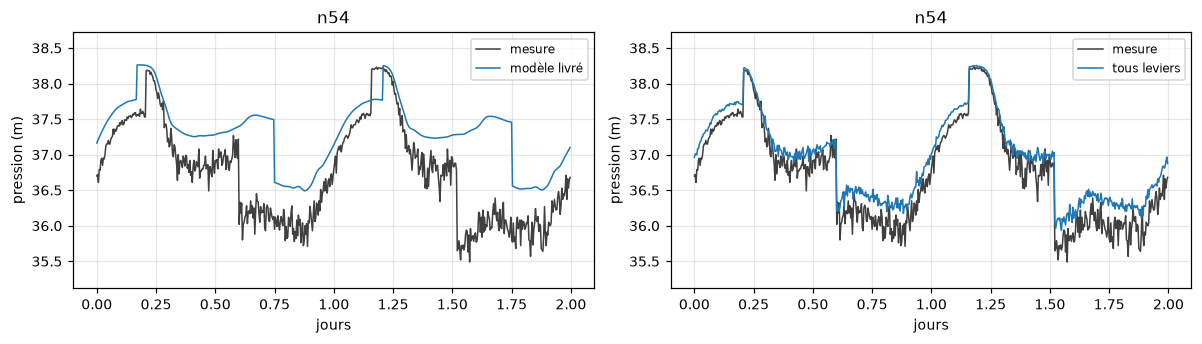

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
G.tracer_capteur(axes[0], S_depart, mesure, "n54", n_pas=2 * R.PAS_JOUR, etiquette="modèle livré")
G.tracer_capteur(axes[1], S_bilan, mesure, "n54", n_pas=2 * R.PAS_JOUR, etiquette="tous leviers")
for ax in axes:
    ax.set_ylim(np.percentile(mesure[:2 * R.PAS_JOUR, R.capteurs()["pressure"].index("n54")],
                              [0.5, 99.5]) + np.array([-0.5, 0.5]))
fig.tight_layout()


### Ce qu'il faut retenir

1. **Une condition aux limites lue dans un capteur vaut un modèle entier.** Prendre l'état de la
   pompe au débitmètre et réancrer le niveau du réservoir sur son capteur tient en deux lignes et
   retire plus de dispersion que toute la décomposition des compteurs.
2. **Les gains se composent, et pas en s'additionnant.** Le modèle de demande rapporte davantage
   une fois la pompe corrigée qu'il ne le laissait voir seul. Mesurer les améliorations une par
   une, dans un modèle où un autre facteur est encore faux, sous-estime leur valeur commune.
3. **Séparer le biais de la dispersion change les conclusions.** Le recalage sur le bilan de
   masse et l'ajustement des rugosités agissent tous deux presque exclusivement sur le biais.
   Jugés à la RMSE, ils paraissent utiles ; jugés sur la dynamique, ils ne le sont pas.
4. **Deux paramètres réputés calibrables ne le sont pas ici** : la section du réservoir, aliasée
   avec la consommation non comptée de la zone qu'elle alimente, et les rugosités, dans un réseau
   où la conduite médiane perd quelques millimètres de charge. Dans les deux cas le diagnostic
   s'établit par une mesure directe et rapide, sans lancer d'optimisation.

### Ce qui resterait à essayer

L'erreur qui subsiste est majoritairement **dynamique** et non expliquée par les leviers testés.
Trois pistes, par ordre de coût croissant :

* **Raccourcir les tranches d'ancrage** — le levier 2 se resserre mécaniquement, et le coût est
  seulement du temps de calcul.
* **Estimer la répartition spatiale de la demande** plutôt que son niveau : le bilan de masse
  contraint la somme sur la zone A+B, pas la façon dont elle se répartit entre 690 nœuds.
* **Regarder les réducteurs de pression.** Ils fixent la charge de tout l'aval, et leur consigne
  est, comme le diamètre du réservoir, un nombre rond dans le fichier. Une consigne fausse de
  quelques centimètres déplacerait en bloc toute une sous-zone — ce qui ressemble beaucoup à ce
  que fait le biais résiduel.